<a href="https://colab.research.google.com/github/kevengoncalves-git/tecnicas_adversarias/blob/Edu/Inserir_N_gramas_de_Shap_em_EXE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install Shap

#Bibliotecas Importadas

In [ ]:
import pandas as pd
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier

In [ ]:
import numpy as np

#Importar DataSet

In [ ]:
df_test = pd.read_csv('test.csv')
df_train = pd.read_csv('train.csv')

#Criação do Soft Volting

In [ ]:
#melhores resultados 4gramas
lr_clf = LogisticRegression(C=0.1, max_iter=150, solver='liblinear')
ext_clf = ExtraTreesClassifier(criterion='entropy', max_depth=6, n_estimators=250)
ad_clf = AdaBoostClassifier(learning_rate=0.1, n_estimators=300)

sf_clf = VotingClassifier(
    estimators=[('lr', lr_clf), ('ext', ext_clf), ('ad', ad_clf)],
    voting='soft')

# SHAP

In [ ]:
df_test = shuffle(df_test)
df_test

In [ ]:
X, y = df_train.drop(["RG", "Filename", "Family", "ID"], axis=1), df_train['RG']

In [ ]:
X_test, y_test = df_test.drop(["RG", "Filename", "Family", "ID"], axis=1), df_test['RG']

In [ ]:
y_test.value_counts()

In [ ]:
modelo.fit(X,y)

In [ ]:
res = modelo.predict(X_test)
print('Acc: ',accuracy_score(y_test,res)*100)
print('Prec: ',precision_score(y_test,res)*100)
print('Rec: ',recall_score(y_test,res)*100)
print('F1: ',f1_score(y_test,res)*100)

In [ ]:
def comparar_arrays(array1, array2):
  """
  Compara dois arrays de tamanhos iguais e retorna um array booleano com True
  onde os valores comparados são iguais e False onde são diferentes.

  Args:
    array1: O primeiro array.
    array2: O segundo array.

  Returns:
    Um array booleano do mesmo tamanho, indicando as posições com valores iguais (True) e diferentes (False).
  """
  if len(array1) != len(array2):
    raise ValueError("Os arrays devem ter o mesmo tamanho.")

  resultado = []
  for i in range(len(array1)):
    resultado.append(array1[i] != array2[i])

  return resultado


In [ ]:
misclassified = comparar_arrays(modelo.predict(X_test), y_test.values)
print(misclassified)

In [ ]:
explainer = shap.Explainer(modelo.predict_proba, X)
shap_values = explainer(X_test, max_evals=4000) # Número ainda não decidido # maior que 3285

PermutationExplainer explainer: 519it [39:55,  4.64s/it]


In [ ]:
shap_values.base_values[1][1]

0.5633333333333334

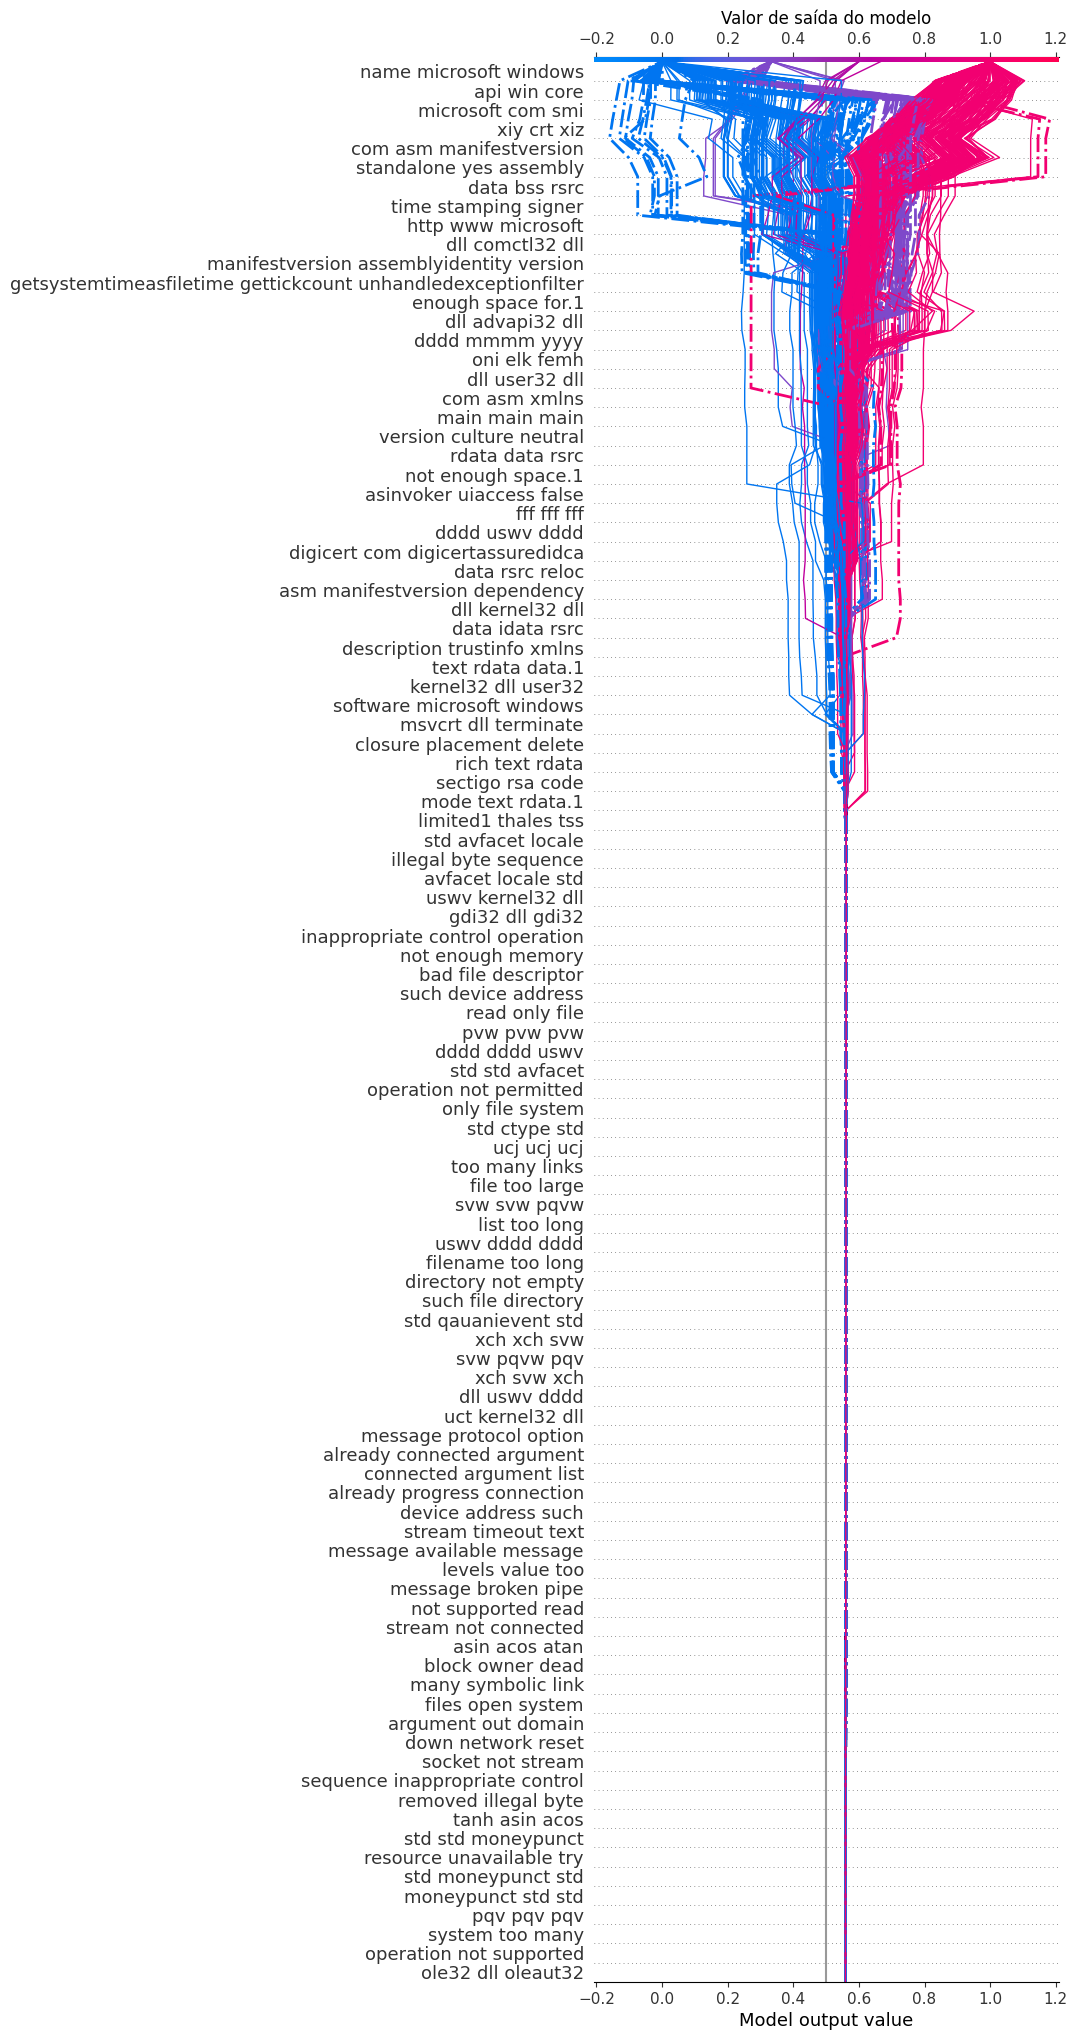

In [ ]:
# com predict_proba
shap.plots.decision(shap_values.base_values[1][1],shap_values[...,1].values,
                   highlight=misclassified,
                   features=X_test,
                   feature_display_range=slice(-1, -101, -1),
                    new_base_value=0.5,
                    # xlim=(-0.05,1.05),
                    auto_size_plot = False,
                    title="Valor de saída do modelo",
                    show=False,
                    ignore_warnings=True # Add this argument
                   )
plt.gcf().set_size_inches(6,25)
plt.savefig(f'decision_proba_{modelo.__class__.__name__}_allfamily.pdf', format='pdf', dpi=600, bbox_inches='tight')
plt.show()

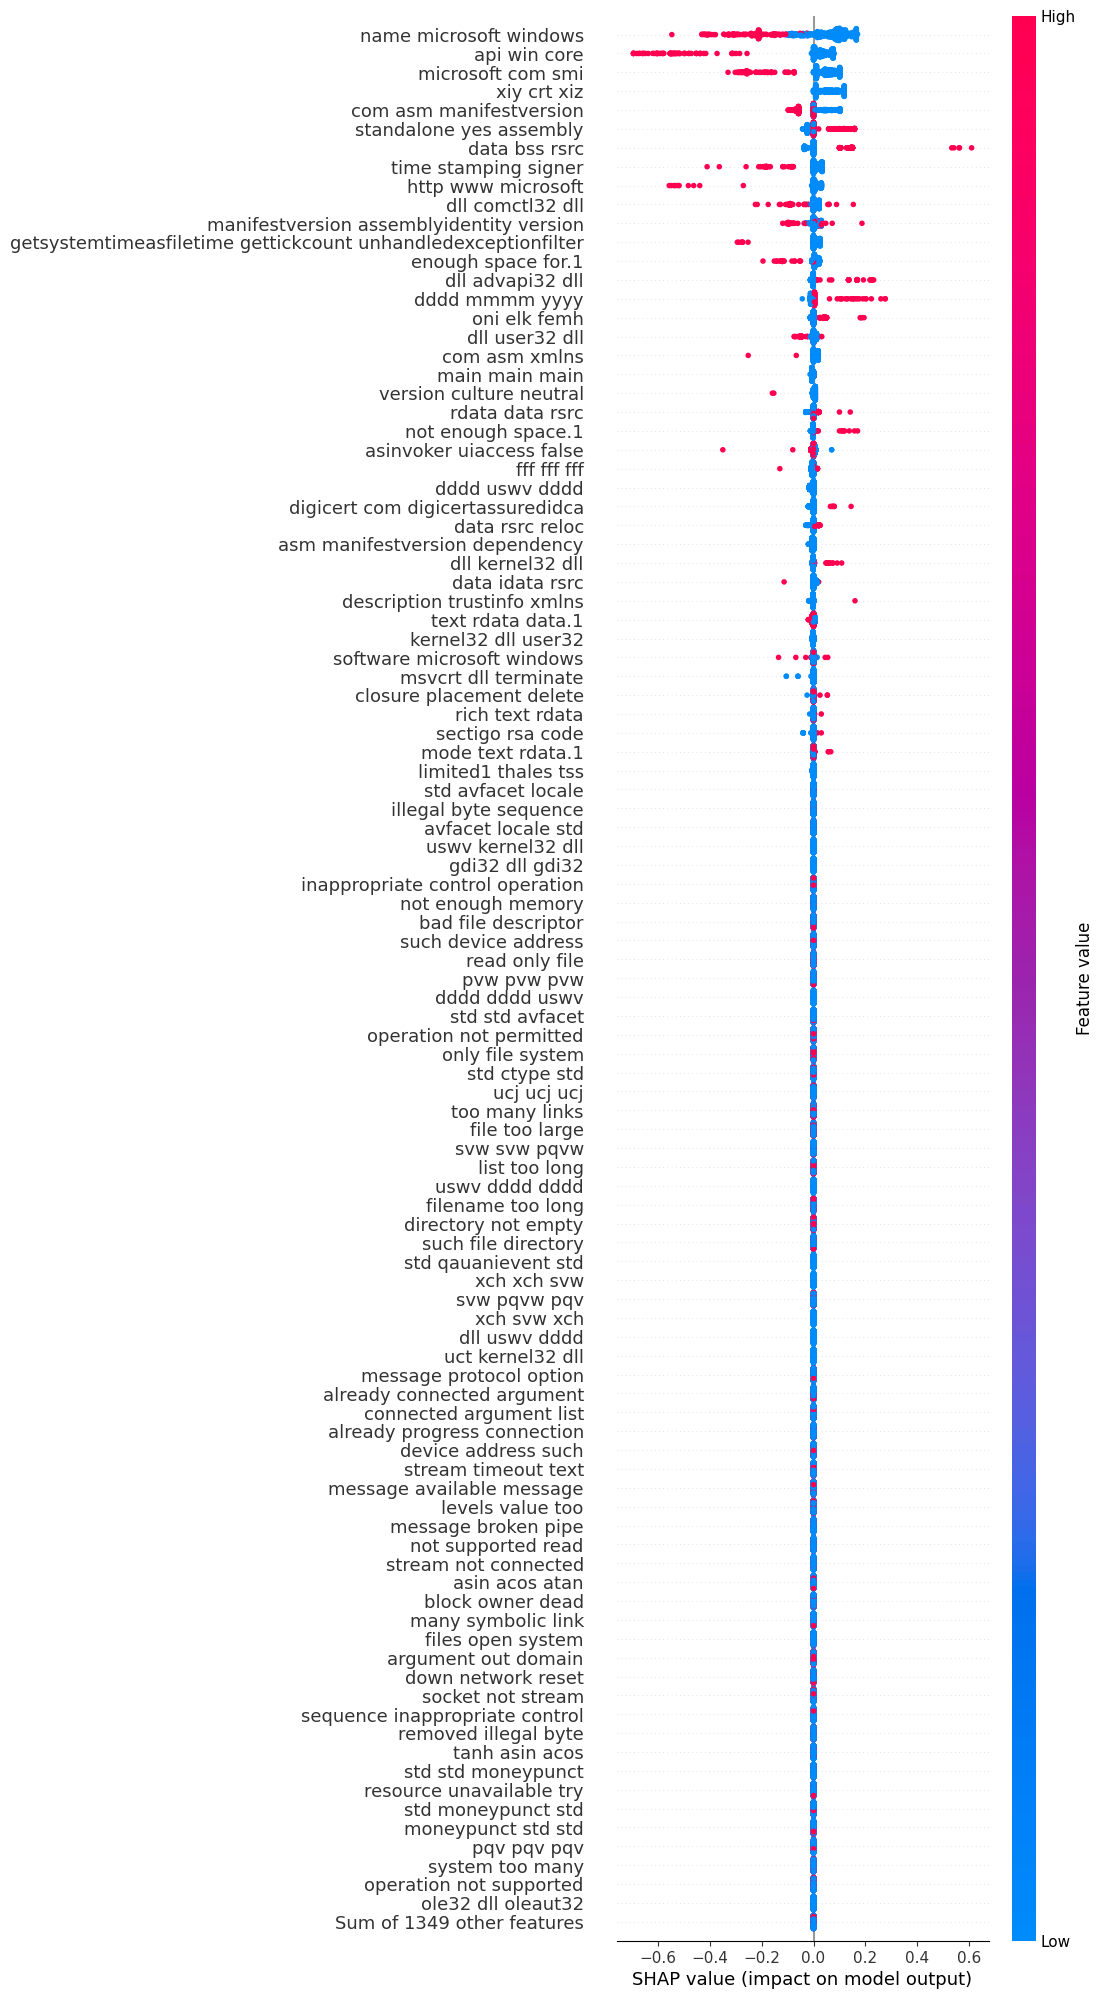

In [ ]:
fig = plt.figure()
shap.plots.beeswarm(shap_values[...,1], max_display=101,show = False)
plt.gcf().set_size_inches(6,25)
plt.savefig(f'beeswarm_{modelo.__class__.__name__}_allfamily.pdf', format='pdf', dpi=600, bbox_inches='tight')
plt.show()